# GPT로 챗봇 만들기 [프로젝트]

지난 Transformer 프로젝트(한국어-영어 번역기) 코드를 기반으로, GPT 논문에 맞춰
수정하고 `ChatbotData.csv`로 언어모델 사전학습까지 진행합니다.


## 0. Transformer 대비 변경이 필요한 부분

번역(seq2seq)은 "다른 언어 시퀀스를 참고해서" 출력을 만들지만, GPT는 "지금까지 나온 토큰만
보고 다음 토큰을 예측"하는 언어모델이라 아키텍처를 아래처럼 블록 단위로 바꿔야 합니다.

| # | 블록 | Transformer (지난 코드) | GPT (이번 코드) | 왜 |
|---|---|---|---|---|
| 1 | 전체 구조 | Encoder + Decoder | **Decoder만** | 참고할 다른 시퀀스가 없으므로 Encoder 자체가 불필요 |
| 2 | 입력 형태 | 소스/타겟 두 시퀀스 | Q+A를 `<SEP>`로 이어붙인 **하나의 시퀀스** | 입력이 하나뿐인 Decoder-only 구조라서 (GPT 논문 3.3절 traversal-style) |
| 3 | DecoderLayer | Self-Attn → Enc-Dec Attn → FFN | Self-Attn → FFN  | 참고할 인코더 출력이 없음 |
| 4 | 위치 정보 | 고정 sin/cos PE (buffer) | **학습되는 Position Embedding** | 논문 4.1절 "learned position embeddings instead of the sinusoidal version" |
| 5 | 활성함수 | ReLU | **GELU** | 논문 4.1절 |
| 6 | 토크나이저 | SentencePiece 기본값(Unigram) | **`model_type='bpe'` 명시** | 논문 4.1절 "a bytepair encoding (BPE) vocabulary" |
| 7 | 학습 목적함수 | 번역 정답과의 Cross-Entropy | **다음 토큰 예측(Causal LM)** Cross-Entropy | 논문 식 (1) — 정답이 시퀀스 자기 자신을 한 칸 민 것 |
| 8 | 규모 | n_layers=2, d_model=512 (논문 6층에서 축소) | n_layers=4, d_model=256, n_heads=4, d_ff=1024 (논문 12층·768차원에서 축소) | 데이터 규모(1.2만 쌍)·Colab 환경 고려 |

각 변경점은 아래 코드에도 `# [GPT 변경]` 주석으로 표시했습니다.


## 0. 환경 준비

In [ ]:
!apt-get -qq install -y fonts-nanum > /dev/null

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

%config InlineBackend.figure_format = 'retina'

fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(fontpath)
plt.rc('font', family=fm.FontProperties(fname=fontpath).get_name())
plt.rc('axes', unicode_minus=False)

print("슝=3")


슝=3


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

import re
import os
import random
import math

import pandas as pd
import sentencepiece as spm
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(torch.__version__)
print("device:", device)        # cuda 가 나와야 GPU 가 잘 연결된 것입니다.


2.11.0+cu128
device: cuda


## Step 1. 데이터 로드

`ChatbotData.csv`를 구글 드라이브에 올려두고 마운트해서 불러옵니다.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_DIR = 'gpt_data'
os.makedirs(DATA_DIR, exist_ok=True)

CSV_PATH = '/content/drive/MyDrive/aiffel_data/ChatbotData.csv'  # 직접 드라이브에 업로드한 경로
df = pd.read_csv(CSV_PATH)
print(df.shape)
df.head()


(11823, 3)


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


## Step 2. 데이터 정제
---
Q, A 각각을 정제합니다. 트랜스포머 코드에서 숫자(0-9)를 추가했습니다.

이번 데이터에는 "1지망", "3박4일" 처럼 숫자가 포함된 문장이 있어서 그대로 쓰면 숫자가 전부 지워집니다.


In [ ]:
def preprocess_sentence(sentence):
    sentence = sentence.lower()
    sentence = re.sub(r"[^0-9a-z가-힣?.!,]+", " ", sentence)  # [GPT 변경] 0-9 추가 (데이터에 숫자 포함되도록)
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"\s+", " ", sentence)
    return sentence.strip()


questions = [preprocess_sentence(q) for q in df['Q']]
answers = [preprocess_sentence(a) for a in df['A']]

print(questions[:3])
print(answers[:3])


['12시 땡 !', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다']
['하루가 또 가네요 .', '위로해 드립니다 .', '여행은 언제나 좋죠 .']


## Step 3. 데이터 토큰화 (SentencePiece)
---
트랜스포머 때는 한국어와 영어 토크나이저를 따로 학습했지만, 이번엔 Q/A가 모두 한국어이고
결국 한 시퀀스로 합쳐지므로 토크나이저 하나만 공용으로 학습합니다. 이번에는 논문에 나왔던 `model_type='bpe'`와 `<sep>`를 사용합니다.


In [ ]:
def generate_tokenizer(corpus, vocab_size, prefix,
                       pad_id=0, bos_id=1, eos_id=2, unk_id=3):
    corpus_path  = os.path.join(DATA_DIR, f"{prefix}_corpus.txt")
    model_prefix = os.path.join(DATA_DIR, f"{prefix}_spm")

    with open(corpus_path, "w", encoding="utf-8") as f:
        for row in corpus:
            f.write(row + "\n")

    spm.SentencePieceTrainer.train(
        input=corpus_path,
        model_prefix=model_prefix,
        vocab_size=vocab_size,
        model_type='bpe',                  # [GPT 변경] 기본값 unigram 대신 BPE (논문 4.1절)
        pad_id=pad_id, bos_id=bos_id, eos_id=eos_id, unk_id=unk_id,
        user_defined_symbols=['<sep>'],    # [GPT 변경] Q/A를 이어붙일 구분자 토큰 추가
    )

    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load(f"{model_prefix}.model")
    return tokenizer


VOCAB_SIZE = 8000  # 데이터 규모가 작아 지난 프로젝트 보다 축소

corpus = questions + answers  # [GPT 변경] src/tgt 분리 없이 Q+A 어휘를 공용으로 학습
tokenizer = generate_tokenizer(corpus, VOCAB_SIZE, "chatbot")

SEP_ID = tokenizer.piece_to_id('<sep>')
PAD_ID, BOS_ID, EOS_ID, UNK_ID = tokenizer.pad_id(), tokenizer.bos_id(), tokenizer.eos_id(), tokenizer.unk_id()

print("PAD/BOS/EOS/UNK/SEP:", PAD_ID, BOS_ID, EOS_ID, UNK_ID, SEP_ID)
print(tokenizer.encode_as_pieces(questions[0]))


PAD/BOS/EOS/UNK/SEP: 0 1 2 3 4
['▁12', '시', '▁땡', '▁!']


이제 `<BOS> Q <SEP> A <EOS>` 형태로 Q, A를 하나의 시퀀스로 합칩니다 (GPT 논문 3.3절 —
구조화된 입력을 하나의 이어진 시퀀스로 변환).


In [ ]:
MAX_LEN = 40  # Q+A 를 합친 길이. 하지만 이번 데이터의 문장들이 짧으므로 40으로 충분해 보임.

sequences = []
for q, a in tqdm(list(zip(questions, answers))):
    q_ids = tokenizer.encode_as_ids(q)
    a_ids = tokenizer.encode_as_ids(a)
    seq = [BOS_ID] + q_ids + [SEP_ID] + a_ids + [EOS_ID]  # [GPT 변경] src/tgt 두 시퀀스 대신 하나로 결합

    if len(seq) <= MAX_LEN:
        sequences.append(torch.tensor(seq, dtype=torch.long))

print(f"사용 시퀀스 수: {len(sequences):,} / {len(questions):,}")


def pad_sequences(sequences, padding_value=0):
    return torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True, padding_value=padding_value)

all_data = pad_sequences(sequences, padding_value=PAD_ID)

print(all_data.shape)
print(all_data[0])   # 1(<BOS>)로 시작, <SEP> 이후 A, 끝에 2(<EOS>)+0(<PAD>) 이 이어져야 함


100%|██████████| 11823/11823 [00:00<00:00, 16862.56it/s]


사용 시퀀스 수: 11,821 / 11,823
torch.Size([11821, 36])
tensor([   1, 5551, 6976, 3200,  109,    4, 4485,  215, 5919,    5,    2,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0])


## Step 4. 모델 설계
---
`MultiHeadAttention`은 Transformer와 동일해서 그대로 재사용합니다. 그 외의 코드는 GPT 구조에 맞게 일부 수정합니다.


In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        self.depth = d_model // self.num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask):
        d_k = K.size(-1)
        QK = torch.matmul(Q, K.transpose(-2, -1))

        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        if mask is not None:
            scaled_qk += (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(attentions, V)

        return out, attentions

    def split_heads(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)

        return x

    def combine_heads(self, x):
        batch_size = x.size(0)
        x = x.permute(0, 2, 1, 3)
        x = x.contiguous().view(batch_size, -1, self.d_model)

        return x

    def forward(self, Q, K, V, mask=None):
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)

        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask)

        out = self.combine_heads(out)
        out = self.linear(out)

        return out, attention_weights

print("슝=3")


슝=3


In [ ]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.gelu = nn.GELU()  # [GPT 변경] ReLU -> GELU (논문 4.1절)

    def forward(self, x):
        out = self.gelu(self.w_1(x))
        out = self.w_2(out)

        return out

print("슝=3")


슝=3


In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()

        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)   # 디코더 자기 자신을 보는 어텐션
        # [GPT 변경] enc_dec_attn(인코더 출력을 보는 어텐션) 삭제 — 인코더가 없어 참고할 대상이 없음

        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        # [GPT 변경] norm_3 삭제 (서브레이어 3개 -> 2개)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Masked Multi-Head Attention
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask)
        out = self.dropout(out)
        out += residual

        # [GPT 변경] Encoder-Decoder Attention 서브레이어 삭제

        # Position-Wise Feed Forward Network
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, dec_attn

print("슝=3")


슝=3


In [ ]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

    def forward(self, x, mask):
        out = x
        dec_attns = []

        for i in range(self.n_layers):
            out, dec_attn = self.dec_layers[i](out, mask)
            dec_attns.append(dec_attn)

        return out, dec_attns

print("슝=3")


슝=3


In [ ]:
class GPT(nn.Module):
    # [GPT 변경] Transformer 클래스(Encoder+Decoder를 감싸던 최상위 클래스)를 대체
    def __init__(self,
                 n_layers,
                 d_model,
                 n_heads,
                 d_ff,
                 vocab_size,
                 pos_len,
                 dropout=0.2,
                 shared=True):
        super(GPT, self).__init__()
        self.d_model = d_model

        # [GPT 변경] 인코더/디코더용 임베딩이 따로 있었지만, 어휘가 하나뿐이라 임베딩도 하나
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        # [GPT 변경] 고정 sin/cos PE(buffer) 대신 학습되는 Position Embedding 사용 (논문 h0 = U*We + Wp)
        self.pos_emb = nn.Embedding(pos_len, d_model)

        # [GPT 변경] 논문 4.1절 초기화 방식 N(0, 0.02) 적용 (지난 코드의 1/d_model 기반 초기화 대체)
        nn.init.normal_(self.tok_emb.weight, mean=0.0, std=0.02)
        nn.init.normal_(self.pos_emb.weight, mean=0.0, std=0.02)

        self.dropout = nn.Dropout(dropout)

        # [GPT 변경] self.encoder 삭제, self.decoder만 유지
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)
        self.fc = nn.Linear(d_model, vocab_size)

        self.shared = shared
        if shared:
            self.fc.weight = self.tok_emb.weight  # Weight Sharing은 기존과 동일하게 유지

    def forward(self, x, mask):
        seq_len = x.size(1)
        # [GPT 변경] positional_encoding()으로 미리 계산해두던 것 대신, 위치 인덱스 제공
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(x.size(0), seq_len)

        out = self.tok_emb(x) + self.pos_emb(positions)
        out = self.dropout(out)

        dec_out, dec_attns = self.decoder(out, mask)
        logits = self.fc(self.final_norm(dec_out))

        return logits, dec_attns

print("슝=3")


슝=3


In [ ]:
# 하이퍼파라미터는 데이터 규모와 Colab 환경에 맞게 축소
model = GPT(
    n_layers=4,
    d_model=256,
    n_heads=4,
    d_ff=1024,
    vocab_size=VOCAB_SIZE,
    pos_len=MAX_LEN,
    dropout=0.1,          # 0.2로 높여봤었지만 역효과여서 다시 0.1로 설정
    shared=True
).to(device)

print(model)


GPT(
  (tok_emb): Embedding(8000, 256)
  (pos_emb): Embedding(40, 256)
  (dropout): Dropout(p=0.1, inplace=False)
  (decoder): Decoder(
    (dec_layers): ModuleList(
      (0-3): 4 x DecoderLayer(
        (dec_self_attn): MultiHeadAttention(
          (W_q): Linear(in_features=256, out_features=256, bias=True)
          (W_k): Linear(in_features=256, out_features=256, bias=True)
          (W_v): Linear(in_features=256, out_features=256, bias=True)
          (linear): Linear(in_features=256, out_features=256, bias=True)
        )
        (ffn): PoswiseFeedForwardNet(
          (w_1): Linear(in_features=256, out_features=1024, bias=True)
          (w_2): Linear(in_features=1024, out_features=256, bias=True)
          (gelu): GELU(approximate='none')
        )
        (norm_1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (norm_2): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (final_norm): Layer

## Step 5. 훈련하기
---
검증(validation) 데이터를 따로 떼어 val_loss를 같이 확인하고, epoch를 늘렸을 때 과적합이 보이면 EarlyStopping으로 멈추도록 했습니다. 마스크 생성 → Learning Rate Scheduler·Optimizer → Loss 함수 → `train_step` → 학습 루프(+검증, EarlyStopping) → 생성 확인(`generate`) 순서로 준비합니다.


In [ ]:
# [검증] 과적합 여부를 확인하기 위해 데이터의 10%를 검증(validation)용으로 분리
from sklearn.model_selection import train_test_split

train_idx, val_idx = train_test_split(range(len(all_data)), test_size=0.1, random_state=42)
train_data = all_data[train_idx]
val_data = all_data[val_idx]

print(f"train: {len(train_data)} / val: {len(val_data)}")


train: 10638 / val: 1183


In [ ]:
def generate_padding_mask(seq):
    """<PAD>(0) 위치를 1 로 표시. [B, L] → [B, 1, 1, L]"""
    mask = (seq == 0).float()
    return mask[:, None, None, :]

def generate_causality_mask(size):
    """대각 위(미래 토큰)를 1 로 표시한 상삼각 행렬. [L, L]"""
    return torch.triu(torch.ones(size, size), diagonal=1)

# [GPT 변경] 인코더가 없어 mask 종류가 하나로 줄어듦 (enc_mask/dec_enc_mask 삭제, dec_mask만 남음)
def generate_mask(seq):
    seq_len = seq.shape[1]
    return torch.max(generate_padding_mask(seq), generate_causality_mask(seq_len).to(seq.device))

print("슝=3")


슝=3


In [ ]:
def warmup_cosine_schedule(warmup_steps, total_steps):
    """GPT 논문 4.1절: 처음 2000 스텝 선형 warmup 후 cosine으로 0까지 감소"""
    def lr_lambda(step):
        step = max(step, 1)
        if step < warmup_steps:
            return step / warmup_steps
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * min(progress, 1.0)))
    return lr_lambda

BATCH_SIZE = 64
EPOCHS = 50
PATIENCE = 3   # val_loss 가 3 epoch 연속 개선되지 않으면 조기 종료

steps_per_epoch = len(train_data) // BATCH_SIZE + 1
total_steps = steps_per_epoch * EPOCHS

# [GPT 변경] AI로 Noam(역제곱근 감소) 대신 논문 방식인 warmup+cosine 스케줄, lr도 논문 값(2.5e-4) 사용
optimizer = optim.Adam(model.parameters(), lr=2.5e-4, betas=(0.9, 0.98), eps=1e-9)
scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup_cosine_schedule(steps_per_epoch, total_steps))

n_params = sum(p.numel() for p in model.parameters())
print(f"파라미터 수: {n_params:,}")


파라미터 수: 5,225,792


In [ ]:
loss_object = torch.nn.CrossEntropyLoss(ignore_index=0, label_smoothing=0.1)

def loss_function(real, pred):
    return loss_object(pred.reshape(-1, pred.size(-1)), real.reshape(-1))


In [ ]:
def train_step(batch, model, optimizer, scheduler):
    model.train()
    batch = batch.to(device)

    # [GPT 변경] 소스/타겟 두 텐서 대신, 시퀀스 하나를 한 칸 밀어 입력/정답으로 사용
    # 디코더 입력은 <BOS> ... <SEP> ... (끝 토큰 제외), 정답은 한 칸 밀린 나머지
    dec_in = batch[:, :-1]
    gold = batch[:, 1:]

    mask = generate_mask(dec_in)

    optimizer.zero_grad()
    logits, dec_attns = model(dec_in, mask)

    loss = loss_function(gold, logits)
    loss.backward()

    optimizer.step()
    scheduler.step()

    return loss.item(), dec_attns

print("슝=3")


슝=3


In [ ]:
def generate(sentence, model, tokenizer, max_len=30):
    model.eval()

    sentence = preprocess_sentence(sentence)
    q_ids = tokenizer.encode_as_ids(sentence)
    # [GPT 변경] evaluate()처럼 인코더 입력을 따로 만들지 않고, <BOS> 질문 <SEP> 까지만 주고
    # 나머지(답변)는 모델이 이어서 생성하도록 함
    input_ids = [BOS_ID] + q_ids + [SEP_ID]
    output = torch.tensor([input_ids], device=device)

    with torch.no_grad():
        for _ in range(max_len):
            mask = generate_mask(output)
            logits, _ = model(output, mask)
            predicted_id = logits[0, -1].argmax().item()

            if predicted_id == EOS_ID:
                break

            output = torch.cat([output, torch.tensor([[predicted_id]], device=device)], dim=-1)

    result_ids = output[0, len(input_ids):].tolist()
    return tokenizer.decode_ids(result_ids)

print("슝=3")


슝=3


In [ ]:
examples = [
    "오늘 너무 힘들다",
    "커피 마시고 싶다",
    "1지망 학교 떨어졌어",
    "여자친구랑 헤어졌어",
]

train_losses = []
val_losses = []

model.train()
best_val_loss = float('inf')
early_stop_counter = 0

for epoch in range(EPOCHS):
    total_loss = 0.0

    idx_list = list(range(0, train_data.shape[0], BATCH_SIZE))
    random.shuffle(idx_list)
    t = tqdm(idx_list)

    for batch, idx in enumerate(t):
        batch_loss, dec_attns = train_step(train_data[idx:idx+BATCH_SIZE], model, optimizer, scheduler)
        total_loss += batch_loss

        t.set_description('Epoch %2d' % (epoch + 1))
        t.set_postfix({'Loss': '%.4f' % (total_loss / (batch + 1)),
                       'lr': '%.2e' % scheduler.get_last_lr()[0]})

    avg_train_loss = total_loss / len(idx_list)
    train_losses.append(avg_train_loss)

    # [검증] dropout 등을 끄고(eval), gradient 계산 없이(no_grad) val_data 로 손실만 측정
    model.eval()
    val_loss = 0.0
    val_idx_list = list(range(0, val_data.shape[0], BATCH_SIZE))
    with torch.no_grad():
        for idx in val_idx_list:
            batch = val_data[idx:idx+BATCH_SIZE].to(device)
            dec_in = batch[:, :-1]
            gold = batch[:, 1:]
            mask = generate_mask(dec_in)
            logits, _ = model(dec_in, mask)
            val_loss += loss_function(gold, logits).item()
    val_loss /= len(val_idx_list)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")

    for example in examples:
        print(example, '->', generate(example, model, tokenizer))

    # EarlyStopping: val_loss 가 이전 최고 기록보다 좋아졌으면 카운터 초기화,
    # 나빠지거나 그대로면 카운터 증가 → patience번 연속 개선이 없으면 학습 중단
    # (과적합이 심해지기 전에 멈추기 위함)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0
    else:
        early_stop_counter += 1

    if early_stop_counter >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

    model.train()  # 검증(eval) 동안 꺼뒀던 dropout을 다시 학습 모드로 되돌림


Epoch  1: 100%|██████████| 167/167 [00:05<00:00, 30.48it/s, Loss=7.7135, lr=2.50e-04]


Epoch 1/50 | Train Loss: 7.7135 | Val Loss: 6.7349
오늘 너무 힘들다 -> 
커피 마시고 싶다 -> 
1지망 학교 떨어졌어 -> 
여자친구랑 헤어졌어 -> 


Epoch  2: 100%|██████████| 167/167 [00:05<00:00, 32.94it/s, Loss=6.4978, lr=2.50e-04]


Epoch 2/50 | Train Loss: 6.4978 | Val Loss: 6.3647
오늘 너무 힘들다 -> 좋은 더 더 더 더 더 더 더 더 더 더 거예요 .
커피 마시고 싶다 -> 좋은 더 더 더 더 더 더 더 더 더 더 거예요 .
1지망 학교 떨어졌어 -> 좋은 더 더 더 더 더 더 더 더 더 더 더 더 거예요 .
여자친구랑 헤어졌어 -> 좋은 더 더 더 더 더 더 더 더 더 거예요 .


Epoch  3: 100%|██████████| 167/167 [00:04<00:00, 33.72it/s, Loss=6.2175, lr=2.49e-04]


...

Epoch 24/50 | Train Loss: 3.7438 | Val Loss: 5.4580
오늘 너무 힘들다 -> 조금만 더 버텨보세요 .
커피 마시고 싶다 -> 같이 마셔보세요 .
1지망 학교 떨어졌어 -> 저도 데려가세요 .
여자친구랑 헤어졌어 -> 더 많이 만나보세요 .


Epoch 25: 100%|██████████| 167/167 [00:05<00:00, 32.37it/s, Loss=3.6670, lr=1.29e-04]


Epoch 25/50 | Train Loss: 3.6670 | Val Loss: 5.4543
오늘 너무 힘들다 -> 조금만 더 버텨보세요 .
커피 마시고 싶다 -> 같이 먹고 싶어요 .
1지망 학교 떨어졌어 -> 위로해 드립니다 .
여자친구랑 헤어졌어 -> 더 많이 만나보세요 .


Epoch 26: 100%|██████████| 167/167 [00:05<00:00, 32.45it/s, Loss=3.6024, lr=1.21e-04]


Epoch 26/50 | Train Loss: 3.6024 | Val Loss: 5.4553
오늘 너무 힘들다 -> 조금만 더 버텨보세요 .
커피 마시고 싶다 -> 카페라도 먹고 싶어요 .
1지망 학교 떨어졌어 -> 위로해 드립니다 .
여자친구랑 헤어졌어 -> 더 많이 만나보세요 .
Early stopping triggered at epoch 26


## 결과 확인

학습이 끝난 모델에 새로운 질문을 넣어 출력이 정상적으로 생성되는지 확인합니다.


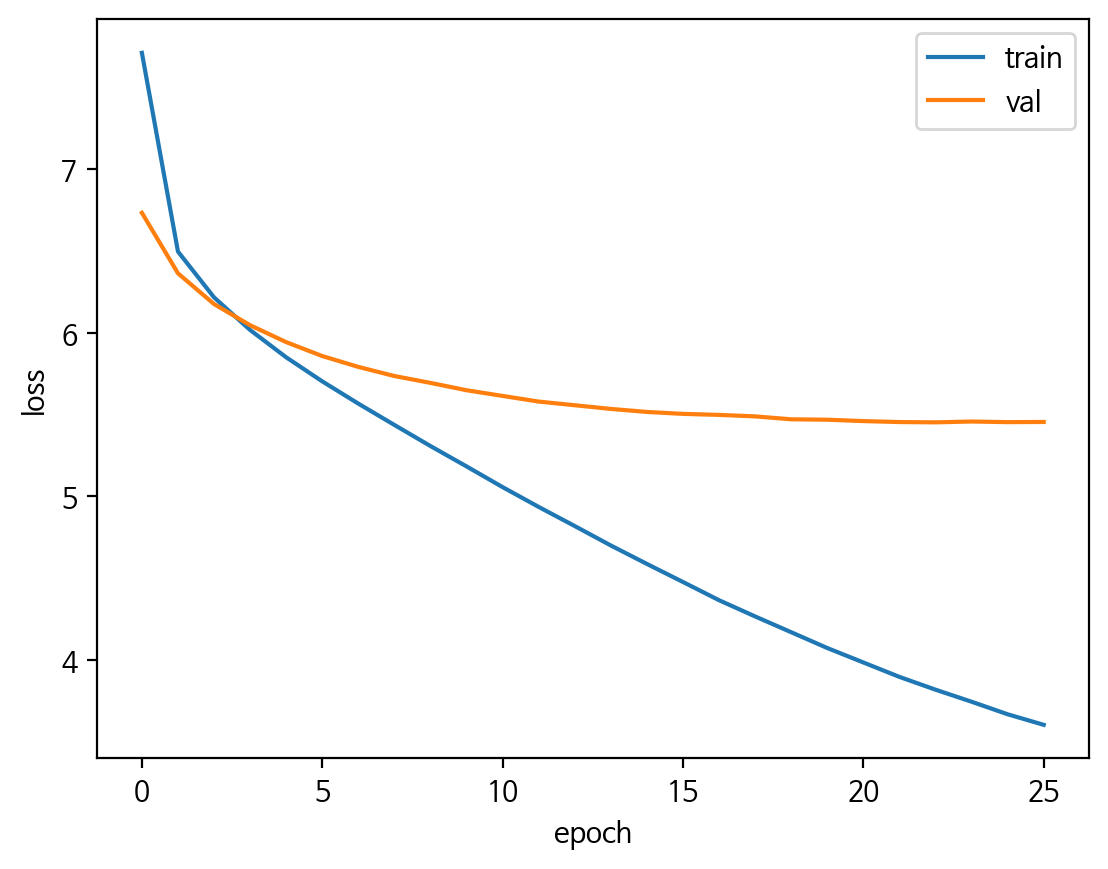

오늘 날씨 진짜 좋다 -> 오늘 일찍 주무세요 .
주말에 뭐하지 -> 저랑 놀아요 .
요즘 너무 우울해 -> 잠시 휴식을 취해보세요 .
취업 준비 힘드네 -> 자신의 감정을 주변 사람들에게 터놓고 이야기해보세요 .


In [ ]:
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

test_questions = ["오늘 날씨 진짜 좋다", "주말에 뭐하지", "요즘 너무 우울해", "취업 준비 힘드네"]

for q in test_questions:
    print(q, '->', generate(q, model, tokenizer))


In [ ]:
test_questions = ["1박 2일 여행갈 거야" , "공부는 왜 어려워?"]

for q in test_questions:
    print(q, '->', generate(q, model, tokenizer))

1박 2일 여행갈 거야 -> 좋은 생각이에요 .
공부는 왜 어려워? -> 확신이 없나봐요 .


## 회고
---


- **최종 Loss:Train Loss: 3.6024 | Val Loss: 5.4553**
- **생성된 답변에 대한 평가**:
전체적으로 꽤 그럴듯해졌다.
하지만 "공부는 왜 어려워? -> 확신이 없나봐요 ." 이 부분은 조금 아쉽다.
- **Transformer 코드를 GPT로 바꾸면서 가장 헷갈렸던/인상적이었던 부분**:
Transformer의 클래스를 대체하는 것이 가장 헷갈렸다.
인상적이었던 것은 질문과 응답의 관계를 이어지는 한 문장으로 정의하고 계산식을 만든 논문의 인사이트가 대단하게 느껴졌다.
- **아쉬웠던 점 / 다음에 시도해보고 싶은 것**:
처음부터 정확도가 좋지는 못해서 많은 시도를 해야 했다. 처음엔 10 에포크를 했고, 학습이 부족했는지 결과가 좋지 못했다. 이후 25 에포크를 돌렸으나 반대로 과적합이 되었는지 답변이 좋다가 나빠졌다. 그래서 과적합 방지를 위해 val_loss와 early stoping을 추가했다. 50에포크를 넣었으나 26에포크에서 멈췄고, 꽤 좋은 모델이 되었다.
거기서 더 개선해보고자, dropout 수치를 0.2로 높여보기도 했으나, 39 에포크를 돌고도 결국 성능이 별로였다.
다음엔 다른 개선 방법들도 시도해보고 싶다.
